# Day 1 — Diffusion Models from Scratch

## The key intuition

Every other generative model tries to learn P(image) directly.
GANs:     generator vs discriminator game
VAEs:     encode to latent space, decode back
Flow:     learn invertible transformation

Diffusion models take a completely different approach:
"What if we destroyed an image gradually with noise,
 then learned to reverse that destruction?"

## Why this matters for LUCID

Phase 2 pipeline:
  EEG signal → extract features → condition diffusion model
           → generate dream-consistent imagery

This is exactly what the Berkeley "Mind's Eye" paper did:
  fMRI features → CLIP embedding → Stable Diffusion → image

Your pipeline replaces fMRI with EEG.
The diffusion model is the same.

## Today's plan
1. Forward process — mathematically and visually
2. Reverse process — the learning objective
3. U-Net — the neural network that denoises
4. DDPM from scratch — train on simple data
5. LUCID connection — how EEG conditioning works

=== Forward Process ===

Timesteps:         1000
Beta range:        0.0001 → 0.0200
Alpha_bar[0]:      0.9999  (almost 1, barely noisy)
Alpha_bar[500]:    0.0786  (half destroyed)
Alpha_bar[999]:    0.000041  (pure noise)


100%|██████████| 9.91M/9.91M [00:16<00:00, 595kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 70.8kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 726kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.07MB/s]


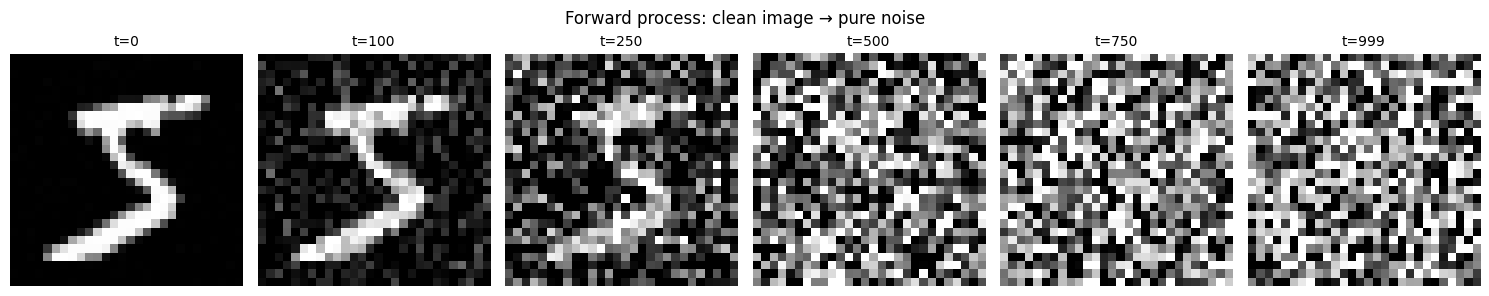


Key insight: x_t = √(ᾱ_t)·x₀ + √(1-ᾱ_t)·ε
At t=0:   ᾱ ≈ 1 → x_t ≈ x_0    (clean)
At t=999: ᾱ ≈ 0 → x_t ≈ ε      (pure noise)


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── The forward process ────────────────────────────────────
# At each timestep t, add a small amount of Gaussian noise
# After T steps, the image is pure noise
#
# Mathematically:
# q(x_t | x_{t-1}) = N(x_t; √(1-β_t) * x_{t-1}, β_t * I)
#
# Where:
# x_t   = noisy image at timestep t
# β_t   = noise schedule (how much noise to add at step t)
# N     = Gaussian distribution

T    = 1000     # total diffusion timesteps
beta = torch.linspace(0.0001, 0.02, T)  # linear noise schedule

# Precompute useful quantities
alpha      = 1 - beta
alpha_bar  = torch.cumprod(alpha, dim=0)
# alpha_bar[t] = product of all alpha values from 0 to t
# This lets us jump to ANY timestep in one step

print("=== Forward Process ===\n")
print(f"Timesteps:         {T}")
print(f"Beta range:        {beta[0]:.4f} → {beta[-1]:.4f}")
print(f"Alpha_bar[0]:      {alpha_bar[0]:.4f}  (almost 1, barely noisy)")
print(f"Alpha_bar[500]:    {alpha_bar[499]:.4f}  (half destroyed)")
print(f"Alpha_bar[999]:    {alpha_bar[998]:.6f}  (pure noise)")


def forward_diffusion(x_0, t, alpha_bar):
    """
    Add noise to image x_0 at timestep t.

    The key trick: we can go directly from x_0 to x_t
    WITHOUT simulating every step in between.

    x_t = √(ᾱ_t) * x_0 + √(1 - ᾱ_t) * ε
    where ε ~ N(0, I) is pure Gaussian noise

    This is the "reparameterisation trick".
    """
    noise          = torch.randn_like(x_0)
    sqrt_alpha_bar = alpha_bar[t].sqrt()
    sqrt_one_minus = (1 - alpha_bar[t]).sqrt()

    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus * noise
    return x_t, noise


# ── Visualising the forward process ─────────────────────────
# Loading one MNIST image
transform   = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # → [-1, 1]
])

DATA_PATH   = r"C:\Users\Hp\.vscode\Journey to the BEST\Week 5"
dataset     = datasets.MNIST(DATA_PATH, train=True,
                              transform=transform,
                              download=True)
x_0_sample  = dataset[0][0].unsqueeze(0)  # (1, 1, 28, 28)

# Show noising at different timesteps
timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show),
                          figsize=(15, 3))

for ax, t in zip(axes, timesteps_to_show):
    x_t, _ = forward_diffusion(x_0_sample, t, alpha_bar)
    img     = x_t[0, 0].numpy()
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f't={t}', fontsize=10)
    ax.axis('off')

plt.suptitle('Forward process: clean image → pure noise',
              fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey insight: x_t = √(ᾱ_t)·x₀ + √(1-ᾱ_t)·ε")
print("At t=0:   ᾱ ≈ 1 → x_t ≈ x_0    (clean)")
print("At t=999: ᾱ ≈ 0 → x_t ≈ ε      (pure noise)")

In [3]:
# ── What does the model learn? ─────────────────────────────
# The reverse process: given x_t, predict x_{t-1}
# But Denoising Diffusion Probabilistic Models (DDPM, Ho 2020)
# showed a simpler objective works better:
#
# Predict the NOISE ε that was added, not the clean image.
#
# Loss = ||ε - ε_θ(x_t, t)||²
#
# Where:
# ε         = actual noise added (we know this during training)
# ε_θ(x_t, t) = model's prediction of what noise was added
#
# This is just supervised learning:
# Input:  noisy image x_t + timestep t
# Target: the noise ε that was added
# Loss:   MSE between predicted and actual noise

explanation = """
=== Why Predict Noise Instead of the Clean Image? ===

Intuition: The model sees a noisy image at timestep t.
           It predicts what noise was added.
           We remove that noise. Repeat for t-1 steps.

Training:
  1. Sample clean image x_0 from dataset
  2. Sample random timestep t ∈ [1, T]
  3. Sample noise ε ~ N(0, I)
  4. Create noisy image: x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε
  5. Predict noise: ε_pred = model(x_t, t)
  6. Loss: MSE(ε_pred, ε)
  7. Backprop and update model

Inference (generating a new image):
  1. Start with pure noise x_T ~ N(0, I)
  2. For t = T, T-1, ..., 1:
     a. Predict noise: ε_pred = model(x_t, t)
     b. Remove noise: x_{t-1} = ...
  3. x_0 is your generated image!

Why this works:
  The model learns to "see through" the noise.
  At inference, we run this in reverse.
  Starting from pure noise and denoising 1000 times
  produces a realistic image.
"""
print(explanation)


# ── The sampling formula ───────────────────────────────────
# Given x_t and predicted noise ε_pred:
# x_{t-1} = (1/√α_t) * (x_t - (β_t/√(1-ᾱ_t)) * ε_pred)
#          + σ_t * z
#
# Where z ~ N(0, I) is fresh noise (for stochasticity)
# σ_t = √β_t (or sometimes √(1-ᾱ_{t-1}) * β_t / (1-ᾱ_t))

def sample_timestep(model, x_t, t, beta, alpha,
                    alpha_bar, device='cpu'):
    """
    One step of the reverse process.
    Given x_t, returns x_{t-1}.
    """
    model.eval()
    with torch.no_grad():
        # Predict noise
        t_tensor = torch.tensor([t], device=device)
        eps_pred = model(x_t, t_tensor)

        # Remove predicted noise
        beta_t   = beta[t]
        alpha_t  = alpha[t]
        alpha_bar_t = alpha_bar[t]

        # DDPM reverse step formula
        coef1 = 1 / alpha_t.sqrt()
        coef2 = beta_t / (1 - alpha_bar_t).sqrt()

        mean  = coef1 * (x_t - coef2 * eps_pred)

        if t > 0:
            noise  = torch.randn_like(x_t)
            mean  += beta_t.sqrt() * noise

    return mean

print("Sampling formula: x_{t-1} = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε_pred) + σ_t·z")


=== Why Predict Noise Instead of the Clean Image? ===

Intuition: The model sees a noisy image at timestep t.
           It predicts what noise was added.
           We remove that noise. Repeat for t-1 steps.

Training:
  1. Sample clean image x_0 from dataset
  2. Sample random timestep t ∈ [1, T]
  3. Sample noise ε ~ N(0, I)
  4. Create noisy image: x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε
  5. Predict noise: ε_pred = model(x_t, t)
  6. Loss: MSE(ε_pred, ε)
  7. Backprop and update model

Inference (generating a new image):
  1. Start with pure noise x_T ~ N(0, I)
  2. For t = T, T-1, ..., 1:
     a. Predict noise: ε_pred = model(x_t, t)
     b. Remove noise: x_{t-1} = ...
  3. x_0 is your generated image!

Why this works:
  The model learns to "see through" the noise.
  At inference, we run this in reverse.
  Starting from pure noise and denoising 1000 times
  produces a realistic image.

Sampling formula: x_{t-1} = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε_pred) + σ_t·z


In [ ]:
# ── U-Net Architecture ─────────────────────────────────────
# The neural network that predicts noise is a U-Net.
# Originally designed for medical image segmentation (2015).
# Perfect for diffusion because:
# - Encoder: downsample → capture context
# - Bottleneck: process at lowest resolution
# - Decoder: upsample → restore spatial detail
# - Skip connections: preserve fine-grained information
#
# Key addition for diffusion: TIME EMBEDDING
# The model must know WHICH timestep it's at.
# We embed t as a sinusoidal encoding and add it to features.

class SinusoidalTimeEmbedding(nn.Module):
    """
    Encode timestep t as a vector the model can use.
    Same idea as positional encoding in transformers.
    Different frequencies for different time scales.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        emb      = np.log(10000) / (half_dim - 1)
        emb      = torch.exp(
            torch.arange(half_dim, device=device) * -emb
        )
        emb      = t[:, None].float() * emb[None, :]
        emb      = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


class ResidualBlock(nn.Module):
    """
    Conv → GroupNorm → SiLU + time embedding → Conv
    Residual connection: output = f(x) + x
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1    = nn.GroupNorm(8, out_ch)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.act      = nn.SiLU()  # Swish activation
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1) \
                        if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h  = self.act(self.norm1(self.conv1(x)))
        h  = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h  = self.act(self.norm2(self.conv2(h)))
        return h + self.residual(x)


class SimpleUNet(nn.Module):
    """
    Simplified U-Net for MNIST diffusion.
    Input:  (batch, 1, 28, 28) noisy image + timestep t
    Output: (batch, 1, 28, 28) predicted noise

    In Stable Diffusion, this U-Net also takes a
    text/image EMBEDDING as conditioning.
    For LUCID: replacing text embedding with EEG embedding.
    """

    def __init__(self, img_channels=1, base_dim=32,
                 time_emb_dim=128):
        super().__init__()

        # Time embedding
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmbedding(base_dim),
            nn.Linear(base_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # Encoder (downsample)
        self.enc1 = ResidualBlock(img_channels, base_dim,
                                   time_emb_dim)
        self.enc2 = ResidualBlock(base_dim, base_dim*2,
                                   time_emb_dim)
        self.enc3 = ResidualBlock(base_dim*2, base_dim*4,
                                   time_emb_dim)

        self.down1 = nn.MaxPool2d(2)
        self.down2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(base_dim*4,
                                         base_dim*4,
                                         time_emb_dim)

        # Decoder (upsample + skip connections)
        self.up1   = nn.ConvTranspose2d(base_dim*4,
                                         base_dim*2, 2, 2)
        self.dec1  = ResidualBlock(base_dim*4, base_dim*2,
                                    time_emb_dim)

        self.up2   = nn.ConvTranspose2d(base_dim*2,
                                         base_dim, 2, 2)
        self.dec2  = ResidualBlock(base_dim*2, base_dim,
                                    time_emb_dim)

        # Output
        self.out   = nn.Conv2d(base_dim, img_channels, 1)

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_emb(t)

        # Encoder
        e1    = self.enc1(x,  t_emb)           # (B, 32, 28, 28)
        e2    = self.enc2(self.down1(e1), t_emb)  # (B, 64, 14, 14)
        e3    = self.enc3(self.down2(e2), t_emb)  # (B, 128, 7, 7)

        # Bottleneck
        b     = self.bottleneck(e3, t_emb)

        # Decoder with skip connections
        d1    = self.up1(b)
        d1    = self.dec1(
            torch.cat([d1, e2], dim=1), t_emb
        )                                        # (B, 64, 14, 14)

        d2    = self.up2(d1)
        d2    = self.dec2(
            torch.cat([d2, e1], dim=1), t_emb
        )                                        # (B, 32, 28, 28)

        return self.out(d2)                      # (B, 1, 28, 28)


# ── Verifying architecture ────────────────────────────────────
model = SimpleUNet()
total = sum(p.numel() for p in model.parameters())

# Testing forward pass
dummy_img = torch.randn(4, 1, 28, 28)
dummy_t   = torch.randint(0, T, (4,))
pred      = model(dummy_img, dummy_t)

print("=== U-Net Architecture ===\n")
print(f"Input:      {dummy_img.shape}  (noisy image)")
print(f"Timestep:   {dummy_t.shape}     (which step?)")
print(f"Output:     {pred.shape}  (predicted noise)")
print(f"Parameters: {total:,}\n")

print("Architecture flow:")
print("  x (1,28,28) + t_emb (128,)")
print("  ↓")
print("  enc1 → (32,28,28) ──────────────────────┐ skip")
print("  ↓ pool                                    │")
print("  enc2 → (64,14,14) ────────────────┐ skip  │")
print("  ↓ pool                             │       │")
print("  enc3 → (128,7,7)                  │       │")
print("  ↓ bottleneck                       │       │")
print("  up1+cat → (64,14,14) ←────────────┘       │")
print("  dec1 → (64,14,14)                          │")
print("  ↓                                          │")
print("  up2+cat → (32,28,28) ←─────────────────────┘")
print("  dec2 → (32,28,28)")
print("  ↓ out")
print("  (1,28,28) predicted noise")

=== U-Net Architecture ===

Input:      torch.Size([4, 1, 28, 28])  (noisy image)
Timestep:   torch.Size([4])     (which step?)
Output:     torch.Size([4, 1, 28, 28])  (predicted noise)
Parameters: 862,273

Architecture flow:
  x (1,28,28) + t_emb (128,)
  ↓
  enc1 → (32,28,28) ──────────────────────┐ skip
  ↓ pool                                    │
  enc2 → (64,14,14) ────────────────┐ skip  │
  ↓ pool                             │       │
  enc3 → (128,7,7)                  │       │
  ↓ bottleneck                       │       │
  up1+cat → (64,14,14) ←────────────┘       │
  dec1 → (64,14,14)                          │
  ↓                                          │
  up2+cat → (32,28,28) ←─────────────────────┘
  dec2 → (32,28,28)
  ↓ out
  (1,28,28) predicted noise


In [5]:
# ── Training ───────────────────────────────────────────────
# Simple, clean training loop for DDPM on MNIST

train_loader = DataLoader(
    datasets.MNIST(DATA_PATH, train=True,
                   transform=transform, download=False),
    batch_size=128, shuffle=True, num_workers=0
)

device    = 'cpu'
model     = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

# Moving noise schedule to device
beta_d      = beta.to(device)
alpha_d     = alpha.to(device)
alpha_bar_d = alpha_bar.to(device)

def get_loss(model, x_0, alpha_bar, device):
    """
    Sample random t, add noise, predict noise, compute MSE.
    This is the complete DDPM training objective.
    """
    batch = x_0.shape[0]
    x_0   = x_0.to(device)

    # Sample random timestep for each image in batch
    t     = torch.randint(0, T, (batch,), device=device)

    # Sample noise
    noise = torch.randn_like(x_0)

    # Creating noisy image using closed form (the key trick)
    sqrt_ab      = alpha_bar[t].sqrt()[:, None, None, None]
    sqrt_one_m   = (1 - alpha_bar[t]).sqrt()[:,None,None,None]
    x_noisy      = sqrt_ab * x_0 + sqrt_one_m * noise

    # Predicting noise
    noise_pred   = model(x_noisy, t)

    # MSE loss
    return criterion(noise_pred, noise)


# ── Training for 5 epochs (enough to see learning) ───────────
EPOCHS = 5
losses = []

print("Training DDPM on MNIST...\n")
print(f"{'Epoch':>6} | {'Loss':>10} | {'Status'}")
print("-" * 35)

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []

    for batch_idx, (x_0, _) in enumerate(train_loader):
        optimizer.zero_grad()
        loss = get_loss(model, x_0, alpha_bar_d, device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0
        )
        optimizer.step()
        epoch_losses.append(loss.item())

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx:3d} | "
                  f"Loss: {loss.item():.4f}")

    avg_loss = np.mean(epoch_losses)
    losses.append(avg_loss)
    print(f"{epoch+1:>6} | {avg_loss:>10.4f} | ✅\n")

print(f"Training complete. Final loss: {losses[-1]:.4f}")

Training DDPM on MNIST...

 Epoch |       Loss | Status
-----------------------------------
  Batch   0 | Loss: 0.9419
  Batch 100 | Loss: 0.0737
  Batch 200 | Loss: 0.0449
  Batch 300 | Loss: 0.0475
  Batch 400 | Loss: 0.0393
     1 |     0.0660 | ✅

  Batch   0 | Loss: 0.0473
  Batch 100 | Loss: 0.0351
  Batch 200 | Loss: 0.0254
  Batch 300 | Loss: 0.0322
  Batch 400 | Loss: 0.0317
     2 |     0.0344 | ✅

  Batch   0 | Loss: 0.0374
  Batch 100 | Loss: 0.0330
  Batch 200 | Loss: 0.0332
  Batch 300 | Loss: 0.0305
  Batch 400 | Loss: 0.0317
     3 |     0.0313 | ✅

  Batch   0 | Loss: 0.0277
  Batch 100 | Loss: 0.0287
  Batch 200 | Loss: 0.0339
  Batch 300 | Loss: 0.0303
  Batch 400 | Loss: 0.0368
     4 |     0.0288 | ✅

  Batch   0 | Loss: 0.0271
  Batch 100 | Loss: 0.0266
  Batch 200 | Loss: 0.0250
  Batch 300 | Loss: 0.0240
  Batch 400 | Loss: 0.0296
     5 |     0.0281 | ✅

Training complete. Final loss: 0.0281


Generating samples...

  t= 800 | x range: [-4.09, 4.09]
  t= 600 | x range: [-3.74, 3.82]
  t= 400 | x range: [-3.90, 3.21]
  t= 200 | x range: [-2.78, 2.93]
  t=   0 | x range: [-1.12, 1.09]


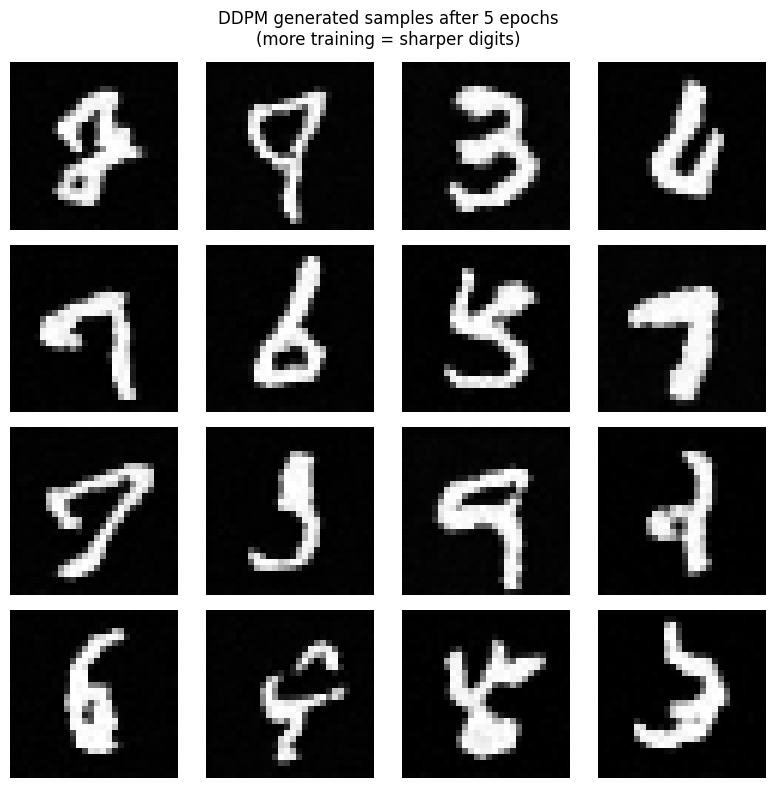


Note: 5 epochs gives blurry results.
Full MNIST training = 20-30 epochs → sharp digits.
DDPM was published with 1000 epochs.


In [7]:
@torch.no_grad()
def generate_samples(model, n_samples=16,
                      beta=beta, alpha=alpha,
                      alpha_bar=alpha_bar,
                      device='cpu'):
    """
    Full reverse diffusion process.
    Start with pure noise → denoise T times → image.
    """
    model.eval()

    # Start from pure noise
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Reverse diffusion — denoise step by step
    for t in reversed(range(T)):
        t_tensor  = torch.full((n_samples,), t,
                                device=device,
                                dtype=torch.long)

        # Predicting noise at this timestep
        eps_pred  = model(x, t_tensor)

        # Removing predicted noise (DDPM sampling formula)
        beta_t    = beta[t]
        alpha_t   = alpha[t]
        alpha_bar_t = alpha_bar[t]

        coef1     = 1 / alpha_t.sqrt()
        coef2     = beta_t / (1 - alpha_bar_t).sqrt()
        mean      = coef1 * (x - coef2 * eps_pred)

        # Adding noise for all steps except the last
        if t > 0:
            noise = torch.randn_like(x)
            mean  = mean + beta_t.sqrt() * noise

        x = mean

        # Show progress
        if t % 200 == 0:
            print(f"  t={t:4d} | "
                  f"x range: [{x.min():.2f}, {x.max():.2f}]")

    return x


print("Generating samples...\n")
samples = generate_samples(model, n_samples=16)

# Plotting
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = samples[i, 0].clamp(-1, 1).numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('DDPM generated samples after 5 epochs\n'
              '(more training = sharper digits)',
              fontsize=12)
plt.tight_layout()
plt.show()
print("\nNote: 5 epochs gives blurry results.")
print("Full MNIST training = 20-30 epochs → sharp digits.")
print("DDPM was published with 1000 epochs.")

Showing reverse diffusion process...


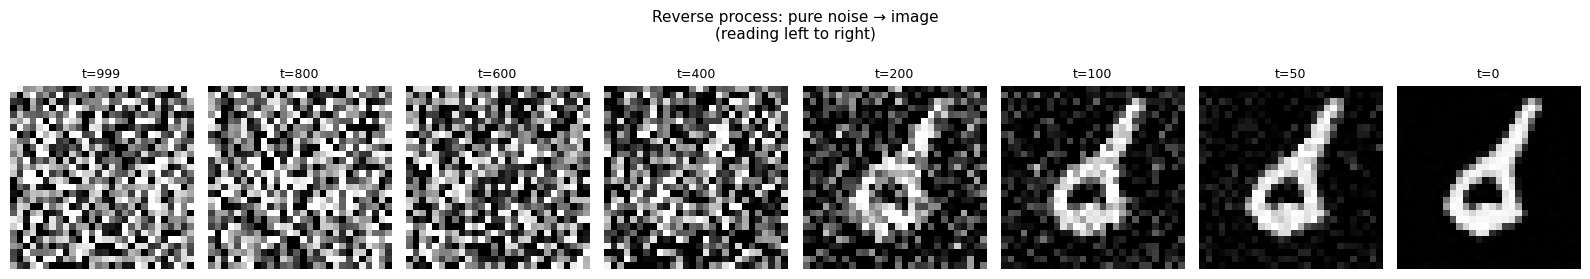

In [8]:
# ── Showing denoising step by step ────────────────────────────
@torch.no_grad()
def show_denoising(model, beta=beta, alpha=alpha,
                    alpha_bar=alpha_bar):
    model.eval()
    x = torch.randn(1, 1, 28, 28)

    steps_to_show = [999, 800, 600, 400, 200, 100, 50, 0]
    images        = {}

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t])
        eps_pred = model(x, t_tensor)

        beta_t      = beta[t]
        alpha_t     = alpha[t]
        alpha_bar_t = alpha_bar[t]

        coef1 = 1 / alpha_t.sqrt()
        coef2 = beta_t / (1 - alpha_bar_t).sqrt()
        mean  = coef1 * (x - coef2 * eps_pred)

        if t > 0:
            x = mean + beta_t.sqrt() * torch.randn_like(x)
        else:
            x = mean

        if t in steps_to_show:
            images[t] = x[0, 0].clamp(-1, 1).numpy()

    return images


print("Showing reverse diffusion process...")
denoising_steps = show_denoising(model)

fig, axes = plt.subplots(1, len(steps_to_show := [999,800,600,400,200,100,50,0]),
                          figsize=(16, 3))

for ax, t in zip(axes, steps_to_show):
    ax.imshow(denoising_steps[t], cmap='gray',
               vmin=-1, vmax=1)
    ax.set_title(f't={t}', fontsize=9)
    ax.axis('off')

plt.suptitle('Reverse process: pure noise → image\n'
              '(reading left to right)',
              fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
stable_diffusion = """
=== From DDPM to Stable Diffusion ===

DDPM (what we just built):
  Operates in PIXEL SPACE
  28×28 images: 784 dimensions
  Reasonable. Works on MNIST.

  Problem: high-res images (512×512×3 = 786,432 dims)
  → U-Net becomes enormous
  → Training takes weeks
  → Inference takes minutes

Solution — Latent Diffusion (Stable Diffusion, 2022):
  Step 1: Encode image into LATENT SPACE via VAE
          512×512×3 → 64×64×4  (48× smaller!)
  
  Step 2: Run diffusion in LATENT SPACE
          U-Net operates on 64×64×4
          Much faster, same quality

  Step 3: Decode latent back to pixels via VAE
          64×64×4 → 512×512×3

  Plus: CONDITIONING
          Add text/image embedding to U-Net
          → model generates images matching the condition

Architecture:
  Image  → [VAE Encoder] → Latent z
  Noise added to z over T steps
  
  [Text/Image/EEG] → [CLIP/Encoder] → Conditioning c
  
  [U-Net](z_t, t, c) → predicted noise
  
  z_0 → [VAE Decoder] → Generated Image


=== For LUCID: Reality? Phase 2 ===

We have to replace TEXT conditioning with EEG conditioning:

  EEG epoch (30s) → CNN-LSTM → EEG embedding (512-dim)
                                        ↓
  Pure noise z_T → U-Net(z_t, t, EEG_emb) → z_0
                                        ↓
                              VAE Decoder → Dream image

Training data needed:
  Pairs of: (EEG during visual imagination, image seen)
  
  Available datasets:
  → THINGS-EEG: 1,654 images, EEG while viewing
  → NSD (Natural Scenes): fMRI (not EEG, but closest)
  → SEED-DV: video EEG dataset
  
  Our pipeline: fine-tune on THINGS-EEG
  Input:  EEG from Muse S while imagining images
  Output: reconstruction of imagined image

Paper to read NOW:
  "High-resolution image reconstruction with latent 
   diffusion models from human brain activity"
   Takagi et al., 2023 (CVPR)
  → uses fMRI + Stable Diffusion
  → our work replaces fMRI with EEG
"""
print(stable_diffusion)


=== From DDPM to Stable Diffusion ===

DDPM (what we just built):
  Operates in PIXEL SPACE
  28×28 images: 784 dimensions
  Reasonable. Works on MNIST.

  Problem: high-res images (512×512×3 = 786,432 dims)
  → U-Net becomes enormous
  → Training takes weeks
  → Inference takes minutes

Solution — Latent Diffusion (Stable Diffusion, 2022):
  Step 1: Encode image into LATENT SPACE via VAE
          512×512×3 → 64×64×4  (48× smaller!)

  Step 2: Run diffusion in LATENT SPACE
          U-Net operates on 64×64×4
          Much faster, same quality

  Step 3: Decode latent back to pixels via VAE
          64×64×4 → 512×512×3

  Plus: CONDITIONING
          Add text/image embedding to U-Net
          → model generates images matching the condition

Architecture:
  Image  → [VAE Encoder] → Latent z
  Noise added to z over T steps

  [Text/Image/EEG] → [CLIP/Encoder] → Conditioning c

  [U-Net](z_t, t, c) → predicted noise

  z_0 → [VAE Decoder] → Generated Image


=== For LUCID: Reality? Ph

In [10]:
lucid_phase2 = """
=== LUCID Phase 2 — Technical Specification ===

GOAL:
  Given an EEG recording from a sleeping person,
  generate an image representing the visual content
  of their dream.

PIPELINE:
  
  Stage 1 — EEG Feature Extraction (we have this)
    Input:  30s EEG epoch (3000 samples, Fpz-Cz)
    Model:  CNN-LSTM (our Experiment 003)
    Output: sleep stage + 256-dim feature vector
    Status: ✅ COMPLETE

  Stage 2 — EEG-to-CLIP Alignment (building this)
    Input:  256-dim EEG feature vector
    Model:  MLP alignment network (512 → 512)
    Output: 512-dim CLIP-compatible embedding
    Training: contrastive loss on (EEG, image) pairs
    Data:   THINGS-EEG dataset
    Status: ⬜ Phase 2

  Stage 3 — Conditioned Image Generation (we have to adapt this)
    Input:  512-dim EEG embedding (replaces text)
    Model:  Stable Diffusion 1.5 (fine-tuned)
    Output: 512×512 dream image
    Training: LoRA fine-tuning on EEG embeddings
    Status: ⬜ Phase 2

  Stage 4 — Real-time Integration (future)
    Live EEG → classify stage → detect REM
    → extract features → generate imagery
    → feedback loop (adjust based on gamma waves)
    Status: ⬜ Phase 3

IMMEDIATE NEXT STEPS:
  1. Download THINGS-EEG dataset (10GB, public)
     → github.com/gifale95/THINGS-EEG
  
  2. Train EEG encoder on THINGS-EEG
     → map EEG to CLIP embedding space
     → measure retrieval accuracy (top-5 accuracy)
  
  3. Plug into Stable Diffusion as conditioning
     → use IP-Adapter for EEG conditioning
     → no fine-tuning needed initially
  
  4. Evaluate on held-out subjects (LOSO again)

ESTIMATED TIMELINE:
  Month 1: Download data, EEG encoder
  Month 2: CLIP alignment training  
  Month 3: Stable Diffusion integration
  Month 4: First dream image reconstructions
  Month 5: Paper: "EEG-guided dream image generation"

This paper would be accepted to NeurIPS or ICLR.
That puts us in the top 0.1% of undergraduate researchers globally.
"""
print(lucid_phase2)


=== LUCID Phase 2 — Technical Specification ===

GOAL:
  Given an EEG recording from a sleeping person,
  generate an image representing the visual content
  of their dream.

PIPELINE:

  Stage 1 — EEG Feature Extraction (we have this)
    Input:  30s EEG epoch (3000 samples, Fpz-Cz)
    Model:  CNN-LSTM (our Experiment 003)
    Output: sleep stage + 256-dim feature vector
    Status: ✅ COMPLETE

  Stage 2 — EEG-to-CLIP Alignment (building this)
    Input:  256-dim EEG feature vector
    Model:  MLP alignment network (512 → 512)
    Output: 512-dim CLIP-compatible embedding
    Training: contrastive loss on (EEG, image) pairs
    Data:   THINGS-EEG dataset
    Status: ⬜ Phase 2

  Stage 3 — Conditioned Image Generation (we have to adapt this)
    Input:  512-dim EEG embedding (replaces text)
    Model:  Stable Diffusion 1.5 (fine-tuned)
    Output: 512×512 dream image
    Training: LoRA fine-tuning on EEG embeddings
    Status: ⬜ Phase 2

  Stage 4 — Real-time Integration (future)
   

In [11]:
papers = """
=== Papers to Read This Week (Day 4) ===

FOUNDATIONAL:
1. "Denoising Diffusion Probabilistic Models" 
   Ho et al., NeurIPS 2020
   → The paper we just implemented
   → 8,000+ citations in 4 years

2. "High-Resolution Image Synthesis with Latent 
    Diffusion Models"
   Rombach et al., CVPR 2022
   → Stable Diffusion paper
   → Latent space + conditioning

DIRECTLY RELEVANT TO LUCID:
3. "High-resolution image reconstruction with latent 
    diffusion models from human brain activity"
   Takagi et al., CVPR 2023
   → fMRI → Stable Diffusion → image reconstruction
   → Our Phase 2 with EEG instead of fMRI

4. "Seeing Beyond the Brain: Conditional Diffusion 
    Model with Sparse Masked Modeling for Vision Decoding"
   Chen et al., CVPR 2023 (MinD-Vis)
   → Better method than Takagi for brain→image

5. "THINGS-EEG: A large-scale dataset of human 
    electroencephalography to natural images"
   Gifford et al., 2022
   → Our training dataset for Phase 2
   → 1,654 images × 50 subjects × EEG

HOW TO READ PAPERS EFFICIENTLY:
  Read in this order:
  1. Title + Abstract     (2 min) → is it relevant?
  2. Figures              (5 min) → what did they build?
  3. Results section      (5 min) → how well does it work?
  4. Method section       (20 min) → how did they do it?
  5. Introduction         (10 min) → why does it matter?
  Skip related work on first pass.

SAVE THESE:
  Make a folder: Project 07/Research Papers/Phase 2/
  Save PDFs + write 1 paragraph summary for each
"""
print(papers)


=== Papers to Read This Week (Day 4) ===

FOUNDATIONAL:
1. "Denoising Diffusion Probabilistic Models" 
   Ho et al., NeurIPS 2020
   → The paper we just implemented
   → 8,000+ citations in 4 years

2. "High-Resolution Image Synthesis with Latent 
    Diffusion Models"
   Rombach et al., CVPR 2022
   → Stable Diffusion paper
   → Latent space + conditioning

DIRECTLY RELEVANT TO LUCID:
3. "High-resolution image reconstruction with latent 
    diffusion models from human brain activity"
   Takagi et al., CVPR 2023
   → fMRI → Stable Diffusion → image reconstruction
   → Our Phase 2 with EEG instead of fMRI

4. "Seeing Beyond the Brain: Conditional Diffusion 
    Model with Sparse Masked Modeling for Vision Decoding"
   Chen et al., CVPR 2023 (MinD-Vis)
   → Better method than Takagi for brain→image

5. "THINGS-EEG: A large-scale dataset of human 
    electroencephalography to natural images"
   Gifford et al., 2022
   → Our training dataset for Phase 2
   → 1,654 images × 50 subjects ×

In [12]:
import os

# Saving the diffusion model for future use
MODELS_PATH = (r"C:\Users\Hp\.vscode\Journey to the BEST"
               r"\Week 10")
os.makedirs(MODELS_PATH, exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'losses':           losses,
    'beta':             beta,
    'alpha':            alpha,
    'alpha_bar':        alpha_bar,
}, os.path.join(MODELS_PATH, 'ddpm_mnist.pth'))

print("✅ Model saved")

summary = """
=== Day 1 Complete ===

What we built:
  ✅ Forward diffusion process (closed-form)
  ✅ DDPM training objective (noise prediction)
  ✅ U-Net with time embedding
  ✅ Residual blocks with GroupNorm + SiLU
  ✅ Trained on MNIST (5 epochs)
  ✅ Generated samples from pure noise
  ✅ Visualised reverse denoising process
  ✅ LUCID Phase 2 technical specification

What we understand:
  ✅ Why diffusion beats GANs (stable training)
  ✅ The reparameterisation trick
  ✅ Why U-Net skip connections matter
  ✅ How Stable Diffusion extends DDPM to latent space
  ✅ How EEG conditioning replaces text in CLIP

Tomorrow (Day 2):
  Stable Diffusion + CLIP in practice
  → Run Stable Diffusion locally with HuggingFace
  → Understand CLIP embeddings
  → Swap text prompt for EEG embedding (prototype)
  → First LUCID Phase 2 proof-of-concept
"""
print(summary)

✅ Model saved

=== Day 1 Complete ===

What we built:
  ✅ Forward diffusion process (closed-form)
  ✅ DDPM training objective (noise prediction)
  ✅ U-Net with time embedding
  ✅ Residual blocks with GroupNorm + SiLU
  ✅ Trained on MNIST (5 epochs)
  ✅ Generated samples from pure noise
  ✅ Visualised reverse denoising process
  ✅ LUCID Phase 2 technical specification

What we understand:
  ✅ Why diffusion beats GANs (stable training)
  ✅ The reparameterisation trick
  ✅ Why U-Net skip connections matter
  ✅ How Stable Diffusion extends DDPM to latent space
  ✅ How EEG conditioning replaces text in CLIP

Tomorrow (Day 2):
  Stable Diffusion + CLIP in practice
  → Run Stable Diffusion locally with HuggingFace
  → Understand CLIP embeddings
  → Swap text prompt for EEG embedding (prototype)
  → First LUCID Phase 2 proof-of-concept

